# Shopping C2 Threshold Tuning

This notebook tunes the Shopping selective-oversight thresholds for
System C2. It keeps the tuning set separate from the held-out test set,
treats no-retry C2 as the primary objective, and writes analysis
artifacts under `outputs/threshold_tuning/`.

## Guardrails

- Shopping only.
- Threshold tuning only.
- Frozen tune/test split required before any tuning run.
- Primary objective uses C2 with `system.final_repair_retry_cap=0`.
- Full C2 can be reported for context, but not used for threshold
  selection.
- The notebook never silently edits core config files.

In [1]:
from __future__ import annotations

import asyncio
import contextlib
import json
import math
import os
import re
import sys
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

from dotenv import load_dotenv
load_dotenv()

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


def resolve_repo_root(start: Path | None = None) -> Path:
    candidates = [start or Path.cwd(), Path.cwd()]
    for candidate in candidates:
        candidate = candidate.resolve()
        for path in [candidate, *candidate.parents]:
            if (path / "pixi.toml").exists() and (path / "configs").exists():
                return path
    raise RuntimeError("Could not locate repo root from the notebook working directory.")


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REQUIRED_FILES = [
    "configs/system/C2.yaml",
    "configs/system/C2-noretry.yaml",
    "configs/shopping/splits.yaml",
    "experiment/config.py",
    "deepplanning/orchestration.py",
    "deepplanning/shopping_runner.py",
    "experiment/logging.py",
]
missing = [path for path in REQUIRED_FILES if not (REPO_ROOT / path).exists()]
if missing:
    raise FileNotFoundError("Missing required repo files: " + ", ".join(missing))

from deepplanning import orchestration
from deepplanning.config import compose_config
from deepplanning.shopping_runner import SHOPPING_ROOT, SHOPPING_SPLITS_PATH
from experiment.config import build_system_config, load_system_defaults
from experiment.logging import StructuredLogger

print(f"Repo root: {REPO_ROOT}")
print(f"Shopping split config: {SHOPPING_SPLITS_PATH}")
print(f"Shopping benchmark data root: {SHOPPING_ROOT}")

Repo root: /Users/dntgafck/msai/thesis/deepplanning-selective-oversight
Shopping split config: /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/configs/shopping/splits.yaml
Shopping benchmark data root: /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/external/qwen-agent/benchmark/deepplanning/shoppingplanning


## Current Defaults And Fixed Assumptions

C2 defaults are loaded from the repo, then the notebook keeps everything
fixed except `loop_similarity_threshold` and `coverage_threshold`.

In [2]:
CONFIG_C2_PATH = REPO_ROOT / "configs/system/C2.yaml"
CONFIG_C2_NORETRY_PATH = REPO_ROOT / "configs/system/C2-noretry.yaml"


def load_yaml(path: Path) -> dict[str, Any]:
    payload = yaml.safe_load(path.read_text(encoding="utf-8"))
    if not isinstance(payload, dict):
        raise ValueError(f"Expected mapping in {path}")
    return payload


c2_defaults = load_yaml(CONFIG_C2_PATH)
c2_noretry_defaults = load_yaml(CONFIG_C2_NORETRY_PATH)

FIXED_ASSUMPTIONS = {
    "loop_window": 5,
    "loop_repeat_count": 3,
    "midpoint": "shopping phase boundary: initial -> cart_check",
    "mutating_tool_semantics": "repo defaults",
    "final_checkpoint_logic": "repo defaults",
    "prompt_version": c2_defaults.get("overseer_prompt_version"),
    "executor_model": "qwen3.5-9b",
    "overseer_model": "deepseek-v4-flash",
}

COARSE_SIMILARITY_THRESHOLDS = [0.90, 0.92, 0.94]
COARSE_COVERAGE_THRESHOLDS = [0.40, 0.50, 0.60]

display(pd.DataFrame([c2_defaults, c2_noretry_defaults], index=["C2", "C2-noretry"]))
display(pd.Series(FIXED_ASSUMPTIONS, name="fixed"))
print("Coarse similarity grid:", COARSE_SIMILARITY_THRESHOLDS)
print("Coarse coverage grid:", COARSE_COVERAGE_THRESHOLDS)

,name,oversight_enabled,oversight_profile,oversight_domains,overseer_thinking,overseer_prompt_version,loop_similarity_threshold,loop_window,loop_repeat_count,coverage_threshold,final_repair_retry_cap,recent_tool_window,inject_transient_notice,irreversible_tools,block_on_mutation_mode,max_hard_blocks_per_args,require_cited_violation_for_block,overseer_call_budget_per_task
C2,C2,True,adaptive_risk,[shopping],True,c2-lite-v1.4-frozen,0.92,5,3,0.5,2,5,True,[],auto,2,True,15
C2-noretry,C2-noretry,True,adaptive_risk,[shopping],True,c2-lite-v1.4-frozen,0.92,5,3,0.5,0,5,True,[],auto,2,True,15


loop_window                                                             5
loop_repeat_count                                                       3
midpoint                   shopping phase boundary: initial -> cart_check
mutating_tool_semantics                                     repo defaults
final_checkpoint_logic                                      repo defaults
prompt_version                                        c2-lite-v1.4-frozen
executor_model                                                 qwen3.5-9b
overseer_model                                          deepseek-v4-flash
Name: fixed, dtype: object

Coarse similarity grid: [0.9, 0.92, 0.94]
Coarse coverage grid: [0.4, 0.5, 0.6]


## Split Loading And Validation

Tuning is only allowed on `configs/shopping/splits.yaml`. The notebook
validates split shape, tune/test non-overlap, and counts by level before
any run helpers are used.

In [3]:
LEVELS = [1, 2, 3]


def load_split_config(path: Path = Path(SHOPPING_SPLITS_PATH)) -> dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(
            f"Frozen Shopping split missing: {path}. "
            "Run the candidate split helper below and explicitly confirm before tuning."
        )
    payload = yaml.safe_load(path.read_text(encoding="utf-8"))
    if not isinstance(payload, dict):
        raise ValueError(f"Shopping split config must be a mapping: {path}")
    return payload


def validate_split_config(payload: dict[str, Any]) -> pd.DataFrame:
    rows = []
    all_tune: set[tuple[int, str]] = set()
    all_test: set[tuple[int, str]] = set()
    for level in LEVELS:
        level_key = f"level_{level}"
        tune = [str(item) for item in payload.get("tune_split", {}).get(level_key, [])]
        test = [str(item) for item in payload.get("test_split", {}).get(level_key, [])]
        if not tune:
            raise ValueError(f"Missing or empty tune_split.{level_key}")
        if not test:
            raise ValueError(f"Missing or empty test_split.{level_key}")
        overlap = sorted(set(tune) & set(test), key=lambda item: int(item))
        if overlap:
            raise ValueError(f"Split overlap for {level_key}: {overlap}")
        all_tune.update((level, item) for item in tune)
        all_test.update((level, item) for item in test)
        rows.append(
            {
                "level": level,
                "tune_count": len(tune),
                "test_count": len(test),
                "total_count": len(tune) + len(test),
            }
        )
    if all_tune & all_test:
        raise ValueError("Tune/test split overlaps across level-qualified sample ids.")
    return pd.DataFrame(rows)


split_payload = load_split_config()
split_summary = validate_split_config(split_payload)
display(split_summary)
display(split_summary[["tune_count", "test_count", "total_count"]].sum().to_frame("count").T)

,level,tune_count,test_count,total_count
0,1,13,37,50
1,2,12,38,50
2,3,5,15,20


,tune_count,test_count,total_count
count,30,90,120


In [4]:
WRITE_CANDIDATE_SPLIT = False
CANDIDATE_SPLIT_SEED = 20260425
CANDIDATE_TUNE_COUNTS_BY_LEVEL = {1: 13, 2: 12, 3: 5}


def load_level_metadata(level: int) -> list[dict[str, Any]]:
    path = Path(SHOPPING_ROOT) / "data" / f"level_{level}_query_meta.json"
    with path.open("r", encoding="utf-8") as fh:
        payload = json.load(fh)
    if not isinstance(payload, list):
        raise ValueError(f"Expected list in {path}")
    return payload


def generate_candidate_split(
    *,
    seed: int = CANDIDATE_SPLIT_SEED,
    tune_counts_by_level: dict[int, int] = CANDIDATE_TUNE_COUNTS_BY_LEVEL,
) -> dict[str, dict[str, list[str]]]:
    rng = np.random.default_rng(seed)
    candidate = {"tune_split": {}, "test_split": {}}
    for level in LEVELS:
        ids = [str(item["id"]) for item in load_level_metadata(level)]
        ids = sorted(ids, key=lambda item: int(item))
        shuffled = list(rng.permutation(ids))
        tune_count = int(tune_counts_by_level[level])
        tune = sorted(shuffled[:tune_count], key=lambda item: int(item))
        test = sorted(shuffled[tune_count:], key=lambda item: int(item))
        candidate["tune_split"][f"level_{level}"] = tune
        candidate["test_split"][f"level_{level}"] = test
    return candidate


candidate_split = generate_candidate_split()
candidate_split_summary = validate_split_config(candidate_split)
display(candidate_split_summary)

if not Path(SHOPPING_SPLITS_PATH).exists():
    print("Frozen split file is absent. Preview the candidate above before writing.")
    if WRITE_CANDIDATE_SPLIT:
        Path(SHOPPING_SPLITS_PATH).parent.mkdir(parents=True, exist_ok=True)
        Path(SHOPPING_SPLITS_PATH).write_text(
            yaml.safe_dump(candidate_split, sort_keys=False),
            encoding="utf-8",
        )
        print(f"Wrote candidate split to {SHOPPING_SPLITS_PATH}")
    else:
        print("Set WRITE_CANDIDATE_SPLIT = True in this cell to write the candidate split.")
else:
    print("Frozen split already exists; candidate generation did not write anything.")

,level,tune_count,test_count,total_count
0,1,13,37,50
1,2,12,38,50
2,3,5,15,20


Frozen split already exists; candidate generation did not write anything.


## Run Controls

Benchmark cells are opt-in. Analysis cells below can reuse existing
artifacts without API keys.

In [5]:
ARTIFACT_ROOT = REPO_ROOT / "outputs/threshold_tuning"
FIGURE_ROOT = ARTIFACT_ROOT / "figures"
BENCHMARK_OUTPUT_ROOT = REPO_ROOT / "outputs/deepplanning/experiments"

RUN_PILOT = False
RUN_COARSE_SWEEP = True
RUN_LOCAL_REFINEMENT = True
RUN_FULL_C2_CONTEXT = False
RUN_TEST_DRY_RUN = False

EXECUTOR_MODEL = FIXED_ASSUMPTIONS["executor_model"]
OVERSEER_MODEL = FIXED_ASSUMPTIONS["overseer_model"]
RUNTIME_WORKERS = 10
RUNTIME_RUNS = 1
RUNTIME_MAX_LLM_CALLS = 400
RUNTIME_INFRA_RETRY_LIMIT = 2

PILOT_TASK_COUNT = 10
BOOTSTRAP_RESAMPLES = 10_000
BOOTSTRAP_SEED = 20260427

ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Analysis artifacts will be written under {ARTIFACT_ROOT}")

Analysis artifacts will be written under /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning


## Candidate And Experiment Helpers

In [6]:
@dataclass(frozen=True)
class ThresholdCandidate:
    stage: str
    loop_similarity_threshold: float
    coverage_threshold: float
    system_name: str = "C2-noretry"
    final_repair_retry_cap: int = 0
    context_label: str = "primary_noretry"

    @property
    def config_id(self) -> str:
        sim = int(round(self.loop_similarity_threshold * 100))
        cov = int(round(self.coverage_threshold * 100))
        return f"{self.stage}-{self.context_label}-sim{sim:03d}-cov{cov:03d}"


@dataclass(frozen=True)
class RunSpec:
    candidate: ThresholdCandidate
    run_stage: str
    split: str
    levels: tuple[int, ...]
    sample_ids: tuple[str, ...] = ()
    suffix: str = ""

    @property
    def name(self) -> str:
        parts = ["threshold-tuning", self.run_stage, self.candidate.config_id]
        if self.suffix:
            parts.append(self.suffix)
        return "-".join(parts)


def coarse_candidates() -> list[ThresholdCandidate]:
    return [
        ThresholdCandidate("coarse", similarity, coverage)
        for similarity in COARSE_SIMILARITY_THRESHOLDS
        for coverage in COARSE_COVERAGE_THRESHOLDS
    ]

coarse_grid = pd.DataFrame([asdict(candidate) | {"config_id": candidate.config_id} for candidate in coarse_candidates()])
display(coarse_grid)

,stage,loop_similarity_threshold,coverage_threshold,system_name,final_repair_retry_cap,context_label,config_id
0,coarse,0.90,0.4,C2-noretry,0,primary_noretry,coarse-primary_noretry-sim090-cov040
1,coarse,0.90,0.5,C2-noretry,0,primary_noretry,coarse-primary_noretry-sim090-cov050
2,coarse,0.90,0.6,C2-noretry,0,primary_noretry,coarse-primary_noretry-sim090-cov060
3,coarse,0.92,0.4,C2-noretry,0,primary_noretry,coarse-primary_noretry-sim092-cov040
4,coarse,0.92,0.5,C2-noretry,0,primary_noretry,coarse-primary_noretry-sim092-cov050
5,coarse,0.92,0.6,C2-noretry,0,primary_noretry,coarse-primary_noretry-sim092-cov060
6,coarse,0.94,0.4,C2-noretry,0,primary_noretry,coarse-primary_noretry-sim094-cov040
7,coarse,0.94,0.5,C2-noretry,0,primary_noretry,coarse-primary_noretry-sim094-cov050
8,coarse,0.94,0.6,C2-noretry,0,primary_noretry,coarse-primary_noretry-sim094-cov060


In [7]:
def ids_for_split(level: int, split: str) -> list[str]:
    key = f"{split}_split"
    level_key = f"level_{level}"
    ids = split_payload.get(key, {}).get(level_key, [])
    if not isinstance(ids, list) or not ids:
        raise ValueError(f"Missing split ids for {key}.{level_key}")
    return [str(item) for item in ids]


def balanced_pilot_ids(total: int = PILOT_TASK_COUNT) -> dict[int, list[str]]:
    tune_counts = {level: len(ids_for_split(level, "tune")) for level in LEVELS}
    total_tune = sum(tune_counts.values())
    raw_counts = {level: total * tune_counts[level] / total_tune for level in LEVELS}
    counts = {level: max(1, int(math.floor(raw_counts[level]))) for level in LEVELS}
    while sum(counts.values()) < total:
        level = max(LEVELS, key=lambda item: raw_counts[item] - counts[item])
        counts[level] += 1
    while sum(counts.values()) > total:
        level = max(LEVELS, key=lambda item: counts[item])
        counts[level] -= 1
    return {level: ids_for_split(level, "tune")[: counts[level]] for level in LEVELS}


def pilot_run_specs(candidate: ThresholdCandidate) -> list[RunSpec]:
    specs = []
    for level, sample_ids in balanced_pilot_ids().items():
        specs.append(
            RunSpec(
                candidate=candidate,
                run_stage="pilot",
                split="all",
                levels=(level,),
                sample_ids=tuple(sample_ids),
                suffix=f"level{level}",
            )
        )
    return specs


def tune_run_spec(candidate: ThresholdCandidate, *, run_stage: str = "coarse") -> RunSpec:
    return RunSpec(candidate=candidate, run_stage=run_stage, split="tune", levels=tuple(LEVELS))


def full_c2_context_candidate(candidate: ThresholdCandidate) -> ThresholdCandidate:
    return ThresholdCandidate(
        stage=candidate.stage,
        loop_similarity_threshold=candidate.loop_similarity_threshold,
        coverage_threshold=candidate.coverage_threshold,
        system_name="C2",
        final_repair_retry_cap=int(c2_defaults.get("final_repair_retry_cap", 2)),
        context_label="full_c2_context",
    )


print("Pilot split preview:")
display(pd.DataFrame([(level, ids) for level, ids in balanced_pilot_ids().items()], columns=["level", "sample_ids"]))

Pilot split preview:


,level,sample_ids
0,1,"[10, 12, 13, 15]"
1,2,"[1, 4, 13, 20]"
2,3,"[2, 12]"


## Launch And Resume Helpers

The public orchestration entry point accepts Hydra overrides, but the
current Shopping runner rebuilds `SystemConfig` from named config files.
The context manager below injects threshold values in-process while
leaving repo config files untouched. The same values are also written to
Hydra overrides so the persisted session metadata records the exact
thresholds used. Launches call `deepplanning.orchestration.run(...)`
through the imported `orchestration.run` entry point. In Jupyter, the
call runs in a worker thread so the Shopping wrapper's internal
`asyncio.run(...)` does not collide with IPython's already-running event
loop.

In [8]:
def hydra_list(values: Sequence[Any]) -> str:
    rendered = []
    for value in values:
        if isinstance(value, (int, float)):
            rendered.append(str(value))
        else:
            rendered.append(json.dumps(str(value)))
    return "[" + ",".join(rendered) + "]"


@contextlib.contextmanager
def temporary_shopping_thresholds(candidate: ThresholdCandidate):
    import experiment.config as experiment_config

    original_frozen = experiment_config._load_frozen_shopping_thresholds
    original_load_defaults = experiment_config.load_system_defaults

    def patched_frozen_thresholds(path: Any = None) -> dict[str, Any]:
        return {
            "loop_similarity_threshold": candidate.loop_similarity_threshold,
            "coverage_threshold": candidate.coverage_threshold,
            "loop_window": FIXED_ASSUMPTIONS["loop_window"],
            "loop_repeat_count": FIXED_ASSUMPTIONS["loop_repeat_count"],
        }

    def patched_load_system_defaults(system_name: str) -> dict[str, Any]:
        payload = dict(original_load_defaults(system_name))
        if system_name in {"C2", "C2-noretry"}:
            payload["loop_similarity_threshold"] = candidate.loop_similarity_threshold
            payload["coverage_threshold"] = candidate.coverage_threshold
            payload["loop_window"] = FIXED_ASSUMPTIONS["loop_window"]
            payload["loop_repeat_count"] = FIXED_ASSUMPTIONS["loop_repeat_count"]
            payload["final_repair_retry_cap"] = candidate.final_repair_retry_cap
        return payload

    experiment_config._load_frozen_shopping_thresholds = patched_frozen_thresholds
    experiment_config.load_system_defaults = patched_load_system_defaults
    try:
        yield
    finally:
        experiment_config._load_frozen_shopping_thresholds = original_frozen
        experiment_config.load_system_defaults = original_load_defaults


def expected_task_count(spec: RunSpec) -> int:
    if spec.sample_ids:
        return len(spec.sample_ids) * RUNTIME_RUNS
    if spec.split != "tune":
        raise ValueError("Only explicit sample_ids or split='tune' are supported by this helper.")
    return sum(len(ids_for_split(level, "tune")) for level in spec.levels) * RUNTIME_RUNS


def build_overrides(spec: RunSpec) -> list[str]:
    candidate = spec.candidate
    overrides = [
        f"name={candidate_safe_name(spec.name)}",
        "domains=[shopping]",
        f"system={candidate.system_name}",
        f"models.executor={EXECUTOR_MODEL}",
        f"models.overseer={OVERSEER_MODEL}",
        f"runtime.workers={RUNTIME_WORKERS}",
        f"runtime.runs={RUNTIME_RUNS}",
        f"runtime.max_llm_calls={RUNTIME_MAX_LLM_CALLS}",
        f"runtime.infra_retry_limit={RUNTIME_INFRA_RETRY_LIMIT}",
        f"shopping.levels={hydra_list(spec.levels)}",
        f"shopping.split={spec.split}",
        f"system.loop_similarity_threshold={candidate.loop_similarity_threshold}",
        f"system.coverage_threshold={candidate.coverage_threshold}",
        f"system.loop_window={FIXED_ASSUMPTIONS['loop_window']}",
        f"system.loop_repeat_count={FIXED_ASSUMPTIONS['loop_repeat_count']}",
        f"system.final_repair_retry_cap={candidate.final_repair_retry_cap}",
        f"output_root={json.dumps(str(BENCHMARK_OUTPUT_ROOT.relative_to(REPO_ROOT)))}",
    ]
    if spec.sample_ids:
        if len(spec.levels) != 1:
            raise ValueError("sample_ids are level-local; run one pilot spec per level.")
        overrides.append(f"shopping.sample_ids={hydra_list(spec.sample_ids)}")
    else:
        overrides.append("shopping.sample_ids=[]")
    return overrides


def candidate_safe_name(value: str) -> str:
    cleaned = re.sub(r"[^A-Za-z0-9._-]+", "-", value).strip("-")
    if not cleaned:
        raise ValueError("Empty experiment name after sanitization.")
    return cleaned


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    rows = []
    if not path.exists():
        return rows
    for line in path.read_text(encoding="utf-8").splitlines():
        if line.strip():
            payload = json.loads(line)
            if isinstance(payload, dict):
                rows.append(payload)
    return rows


def session_roots_for_name(name: str) -> list[Path]:
    root = BENCHMARK_OUTPUT_ROOT / candidate_safe_name(name)
    if not root.exists():
        return []
    return sorted(path for path in root.iterdir() if (path / "experiment_session.json").exists())


def task_result_count(session_root: Path) -> int:
    return sum(len(read_jsonl(path)) for path in session_root.rglob("task_results.jsonl"))


def completed_sessions_for_spec(spec: RunSpec) -> list[Path]:
    expected = expected_task_count(spec)
    return [session for session in session_roots_for_name(spec.name) if task_result_count(session) >= expected]


def running_event_loop_active() -> bool:
    try:
        loop = asyncio.get_running_loop()
    except RuntimeError:
        return False
    return loop.is_running()


def launch_orchestration(spec: RunSpec, overrides: list[str]) -> Path:
    def launch() -> Path:
        with temporary_shopping_thresholds(spec.candidate):
            return Path(orchestration.run(*overrides))

    if running_event_loop_active():
        print("Detected an active Jupyter event loop; launching benchmark in a worker thread.")
        with ThreadPoolExecutor(max_workers=1) as executor:
            return executor.submit(launch).result()
    return launch()


def run_or_reuse(spec: RunSpec, *, allow_launch: bool) -> list[Path]:
    existing = completed_sessions_for_spec(spec)
    if existing:
        print(f"Reuse {spec.name}: {existing[-1]}")
        return existing
    overrides = build_overrides(spec)
    print("Overrides:")
    for override in overrides:
        print("  " + override)
    if not allow_launch:
        print(f"Launch disabled for {spec.name}; set the matching RUN_* flag to True.")
        return []
    session_root = launch_orchestration(spec, overrides)
    print(f"Completed: {session_root}")
    return [Path(session_root)]

## Stage 0: Pilot

In [9]:
pilot_candidate = ThresholdCandidate(
    "pilot",
    loop_similarity_threshold=float(c2_defaults["loop_similarity_threshold"]),
    coverage_threshold=float(c2_defaults["coverage_threshold"]),
)
pilot_sessions: list[Path] = []
for spec in pilot_run_specs(pilot_candidate):
    pilot_sessions.extend(run_or_reuse(spec, allow_launch=RUN_PILOT))
print(f"Pilot sessions available: {len(pilot_sessions)}")

Overrides:
  name=threshold-tuning-pilot-pilot-primary_noretry-sim092-cov050-level1
  domains=[shopping]
  system=C2-noretry
  models.executor=qwen3.5-9b
  models.overseer=deepseek-v4-flash
  runtime.workers=10
  runtime.runs=1
  runtime.max_llm_calls=400
  runtime.infra_retry_limit=2
  shopping.levels=[1]
  shopping.split=all
  system.loop_similarity_threshold=0.92
  system.coverage_threshold=0.5
  system.loop_window=5
  system.loop_repeat_count=3
  system.final_repair_retry_cap=0
  output_root="outputs/deepplanning/experiments"
  shopping.sample_ids=["10","12","13","15"]
Launch disabled for threshold-tuning-pilot-pilot-primary_noretry-sim092-cov050-level1; set the matching RUN_* flag to True.
Overrides:
  name=threshold-tuning-pilot-pilot-primary_noretry-sim092-cov050-level2
  domains=[shopping]
  system=C2-noretry
  models.executor=qwen3.5-9b
  models.overseer=deepseek-v4-flash
  runtime.workers=10
  runtime.runs=1
  runtime.max_llm_calls=400
  runtime.infra_retry_limit=2
  shopping

## Stage 1: Coarse Sweep

In [10]:
coarse_sessions: list[Path] = []
for candidate in coarse_candidates():
    coarse_sessions.extend(run_or_reuse(tune_run_spec(candidate), allow_launch=RUN_COARSE_SWEEP))
print(f"Coarse sessions available: {len(coarse_sessions)}")

Reuse threshold-tuning-coarse-coarse-primary_noretry-sim090-cov040: /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/deepplanning/experiments/threshold-tuning-coarse-coarse-primary_noretry-sim090-cov040/2026-04-28_00-03-24
Reuse threshold-tuning-coarse-coarse-primary_noretry-sim090-cov050: /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/deepplanning/experiments/threshold-tuning-coarse-coarse-primary_noretry-sim090-cov050/2026-04-28_00-41-54
Reuse threshold-tuning-coarse-coarse-primary_noretry-sim090-cov060: /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/deepplanning/experiments/threshold-tuning-coarse-coarse-primary_noretry-sim090-cov060/2026-04-28_01-11-47
Reuse threshold-tuning-coarse-coarse-primary_noretry-sim092-cov040: /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/deepplanning/experiments/threshold-tuning-coarse-coarse-primary_noretry-sim092-cov040/2026-04-28_01-46-34
Reuse threshold-tuning-coars

## Log Ingestion Helpers

In [18]:
def find_session_root(path: Path) -> Path | None:
    for parent in [path, *path.parents]:
        if (parent / "experiment_session.json").exists():
            return parent
    return None


def load_session_metadata(session_root: Path) -> dict[str, Any]:
    path = session_root / "experiment_session.json"
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))


def parse_level_from_path(path: Path) -> int | None:
    for part in path.parts:
        match = re.search(r"level[_-]?(\d+)", part)
        if match:
            return int(match.group(1))
    return None


def parse_run_id_from_path(path: Path) -> int | None:
    for part in path.parts:
        match = re.fullmatch(r"run_(\d+)", part)
        if match:
            return int(match.group(1))
    return None


def threshold_metadata(session_root: Path) -> dict[str, Any]:
    metadata = load_session_metadata(session_root)
    params = metadata.get("parameters", {})
    system = params.get("system", {}) if isinstance(params, dict) else {}
    experiment = metadata.get("experiment", {}) if isinstance(metadata, dict) else {}
    return {
        "session_root": str(session_root),
        "experiment_name": experiment.get("name", session_root.parent.name),
        "system_name": system.get("name"),
        "loop_similarity_threshold": system.get("loop_similarity_threshold"),
        "coverage_threshold": system.get("coverage_threshold"),
        "loop_window": system.get("loop_window"),
        "loop_repeat_count": system.get("loop_repeat_count"),
        "final_repair_retry_cap": system.get("final_repair_retry_cap"),
        "executor_model": (params.get("models", {}) or {}).get("executor") if isinstance(params, dict) else None,
        "overseer_model": (params.get("models", {}) or {}).get("overseer") if isinstance(params, dict) else None,
    }


def discover_threshold_sessions() -> list[Path]:
    sessions = []
    if not BENCHMARK_OUTPUT_ROOT.exists():
        return sessions
    for metadata_path in BENCHMARK_OUTPUT_ROOT.rglob("experiment_session.json"):
        session_root = metadata_path.parent
        metadata = load_session_metadata(session_root)
        name = metadata.get("experiment", {}).get("name", session_root.parent.name)
        if str(name).startswith("threshold-tuning"):
            sessions.append(session_root)
    return sorted(set(sessions))


def load_task_results(session_roots: Iterable[Path]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for session_root in session_roots:
        meta = threshold_metadata(session_root)
        for path in session_root.rglob("task_results.jsonl"):
            level = parse_level_from_path(path)
            path_run_id = parse_run_id_from_path(path)
            for record in read_jsonl(path):
                row = dict(record)
                row.update(meta)
                row["task_id"] = str(row.get("task_id"))
                row["level"] = int(row.get("complexity") or level or 0) or None
                row["run_id"] = int(row.get("run_id") if row.get("run_id") is not None else path_run_id or 0)
                row["task_results_path"] = str(path)
                rows.append(row)
    return pd.DataFrame(rows)


def load_agent_events(session_roots: Iterable[Path]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for session_root in session_roots:
        meta = threshold_metadata(session_root)
        for path in session_root.rglob("agent_events.jsonl"):
            level = parse_level_from_path(path)
            path_run_id = parse_run_id_from_path(path)
            for record in read_jsonl(path):
                row = dict(record)
                row.update(meta)
                row["task_id"] = str(row.get("task_id"))
                row["level"] = level
                row["run_id"] = int(row.get("run_id") if row.get("run_id") is not None else path_run_id or 0)
                row["agent_events_path"] = str(path)
                rows.append(row)
    return pd.DataFrame(rows)


def load_evaluation_results(session_roots: Iterable[Path]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for session_root in session_roots:
        meta = threshold_metadata(session_root)
        for path in session_root.rglob("summary_report.json"):
            level = parse_level_from_path(path)
            run_id = parse_run_id_from_path(path)
            payload = json.loads(path.read_text(encoding="utf-8"))
            for case in payload.get("case_results", []):
                task_id = str(case.get("case_name", "")).replace("case_", "")
                rows.append(
                    {
                        **meta,
                        "task_id": task_id,
                        "level": level,
                        "run_id": int(run_id or 0),
                        "case_accuracy": float(case.get("case_score", 1.0 if case.get("success") else 0.0)),
                        "case_success": bool(case.get("success", False)),
                        "match_score": float(case.get("score")) if case.get("score") is not None else np.nan,
                        "matched_count": case.get("matched_count"),
                        "expected_count": case.get("expected_count"),
                        "extra_products_count": case.get("extra_products_count"),
                        "evaluation_summary_path": str(path),
                    }
                )
    return pd.DataFrame(rows)


available_sessions = sorted(set([*discover_threshold_sessions(), *pilot_sessions, *coarse_sessions]))
print(f"Discovered threshold-tuning sessions: {len(available_sessions)}")

Discovered threshold-tuning sessions: 13


## Metric Computation

In [19]:
task_results_df = load_task_results(available_sessions)
events_df = load_agent_events(available_sessions)
eval_df = load_evaluation_results(available_sessions)


def merge_task_and_eval(task_df: pd.DataFrame, evaluation_df: pd.DataFrame) -> pd.DataFrame:
    if evaluation_df.empty:
        return task_df.copy()
    keys = ["session_root", "run_id", "level", "task_id"]
    if task_df.empty:
        return evaluation_df.copy()
    task_df = task_df.copy()
    evaluation_df = evaluation_df.copy()
    for frame in (task_df, evaluation_df):
        frame["task_id"] = frame["task_id"].astype(str)
    return evaluation_df.merge(
        task_df,
        on=keys,
        how="left",
        suffixes=("", "_task"),
    )


task_metric_df = merge_task_and_eval(task_results_df, eval_df)


def explode_counter(values: Iterable[Any]) -> Counter:
    counter: Counter[str] = Counter()
    for value in values:
        if isinstance(value, dict):
            for key, count in value.items():
                counter[str(key)] += int(count or 0)
        elif isinstance(value, list):
            for item in value:
                if isinstance(item, dict):
                    counter[str(item.get("trigger_type") or item.get("type") or item)] += 1
                else:
                    counter[str(item)] += 1
        elif pd.notna(value):
            counter[str(value)] += 1
    return counter


def summarize_candidate_frame(frame: pd.DataFrame) -> dict[str, Any]:
    if frame.empty:
        return {}
    first = frame.iloc[0]
    retry_counts = pd.to_numeric(frame.get("final_verification_retry_count"), errors="coerce").fillna(0)
    no_retry_mask = retry_counts.eq(0)
    case_accuracy = pd.to_numeric(frame.get("case_accuracy"), errors="coerce")
    match_score = pd.to_numeric(frame.get("match_score"), errors="coerce")
    total_cost = pd.to_numeric(frame.get("total_cost_usd"), errors="coerce")
    overseer_invocations = pd.to_numeric(
        frame.get("overseer_invocation_count", frame.get("overseer_calls")),
        errors="coerce",
    )
    trigger_counter = explode_counter(frame.get("overseer_invocation_count_by_trigger", []))
    if not trigger_counter and "triggers_fired" in frame:
        trigger_counter = explode_counter(frame["triggers_fired"])
    task_count = int(frame[["level", "task_id", "run_id"]].drop_duplicates().shape[0])
    primary_is_noretry = str(first.get("system_name")) == "C2-noretry" or int(first.get("final_repair_retry_cap") or 0) == 0
    primary_accuracy = case_accuracy.mean() if primary_is_noretry else case_accuracy[no_retry_mask].mean()
    return {
        "experiment_name": first.get("experiment_name"),
        "system_name": first.get("system_name"),
        "loop_similarity_threshold": float(first.get("loop_similarity_threshold")),
        "coverage_threshold": float(first.get("coverage_threshold")),
        "loop_window": first.get("loop_window"),
        "loop_repeat_count": first.get("loop_repeat_count"),
        "final_repair_retry_cap": first.get("final_repair_retry_cap"),
        "n_tasks": task_count,
        "n_runs": int(frame["run_id"].nunique()) if "run_id" in frame else 0,
        "mean_case_accuracy": float(case_accuracy.mean()) if case_accuracy.notna().any() else np.nan,
        "mean_match_score": float(match_score.mean()) if match_score.notna().any() else np.nan,
        "mean_total_cost_usd": float(total_cost.mean()) if total_cost.notna().any() else np.nan,
        "mean_overseer_invocation_count": float(overseer_invocations.mean()) if overseer_invocations.notna().any() else np.nan,
        "overseer_invocation_rate": float((overseer_invocations.fillna(0) > 0).mean()) if len(overseer_invocations) else np.nan,
        "primary_case_accuracy": float(primary_accuracy) if pd.notna(primary_accuracy) else np.nan,
        "primary_objective": "C2-noretry" if primary_is_noretry else "first-attempt-only",
        "first_attempt_task_count": int(no_retry_mask.sum()),
        "first_attempt_case_accuracy": float(case_accuracy[no_retry_mask].mean()) if no_retry_mask.any() else np.nan,
        "trigger_counts": dict(trigger_counter),
        "trigger_proportions": {key: value / max(sum(trigger_counter.values()), 1) for key, value in trigger_counter.items()},
        "final_verification_retry_distribution": {str(int(key)): int(value) for key, value in retry_counts.value_counts().sort_index().items()},
    }


def summarize_candidates(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame()
    group_cols = ["experiment_name", "system_name", "loop_similarity_threshold", "coverage_threshold", "final_repair_retry_cap"]
    rows = []
    for _, group in frame.groupby(group_cols, dropna=False):
        rows.append(summarize_candidate_frame(group))
    return pd.DataFrame(rows).sort_values(
        ["system_name", "loop_similarity_threshold", "coverage_threshold"],
        kind="stable",
    )


summary_df = summarize_candidates(task_metric_df)
display(summary_df)

,experiment_name,system_name,loop_similarity_threshold,coverage_threshold,loop_window,loop_repeat_count,final_repair_retry_cap,n_tasks,n_runs,mean_case_accuracy,mean_match_score,mean_total_cost_usd,mean_overseer_invocation_count,overseer_invocation_rate,primary_case_accuracy,primary_objective,first_attempt_task_count,first_attempt_case_accuracy,trigger_counts,trigger_proportions,final_verification_retry_distribution
0,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.90,0.4,5,3,0,30,1,0.333333,0.686111,0.062055,4.300000,1.000000,0.333333,C2-noretry,3,0.666667,"{'loop_detection': 24, 'mutating_action': 70, ...","{'loop_detection': 0.18604651162790697, 'mutat...","{'0': 3, '1': 27}"
1,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.90,0.5,5,3,0,30,1,0.300000,0.660000,0.053114,4.300000,0.966667,0.300000,C2-noretry,2,0.000000,"{'mutating_action': 75, 'error_occurrence': 6,...","{'mutating_action': 0.5813953488372093, 'error...","{'0': 2, '1': 28}"
2,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.90,0.6,5,3,0,30,1,0.266667,0.620556,0.058612,3.800000,0.866667,0.266667,C2-noretry,6,0.166667,"{'mutating_action': 67, 'error_occurrence': 3,...","{'mutating_action': 0.5877192982456141, 'error...","{'0': 6, '1': 24}"
9,threshold-tuning-refine-refine-primary_noretry...,C2-noretry,0.90,0.6,5,3,0,30,1,0.266667,0.604444,0.060356,3.533333,0.933333,0.266667,C2-noretry,3,0.000000,"{'mutating_action': 60, 'final_checkpoint': 28...","{'mutating_action': 0.5660377358490566, 'final...","{'0': 3, '1': 27}"
3,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.92,0.4,5,3,0,30,1,0.266667,0.660556,0.055407,3.500000,0.933333,0.266667,C2-noretry,4,0.000000,"{'mutating_action': 68, 'final_checkpoint': 27...","{'mutating_action': 0.6476190476190476, 'final...","{'0': 4, '1': 26}"
4,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.92,0.5,5,3,0,30,1,0.233333,0.669444,0.052999,3.766667,0.933333,0.233333,C2-noretry,4,0.250000,"{'mutating_action': 72, 'final_checkpoint': 28...","{'mutating_action': 0.6371681415929203, 'final...","{'0': 4, '1': 26}"
5,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.92,0.6,5,3,0,30,1,0.300000,0.696111,0.049997,3.666667,1.000000,0.300000,C2-noretry,2,0.000000,"{'mutating_action': 73, 'final_checkpoint': 30...","{'mutating_action': 0.6636363636363637, 'final...","{'0': 2, '1': 28}"
10,threshold-tuning-refine-refine-primary_noretry...,C2-noretry,0.92,0.6,5,3,0,30,1,0.300000,0.695556,0.057447,5.000000,1.000000,0.300000,C2-noretry,3,0.000000,"{'mutating_action': 98, 'error_occurrence': 11...","{'mutating_action': 0.6533333333333333, 'error...","{'0': 3, '1': 27}"
6,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.94,0.4,5,3,0,30,1,0.400000,0.698889,0.063021,4.600000,0.966667,0.400000,C2-noretry,5,0.400000,"{'mutating_action': 93, 'error_occurrence': 8,...","{'mutating_action': 0.6739130434782609, 'error...","{'0': 5, '1': 25}"
11,threshold-tuning-refine-refine-primary_noretry...,C2-noretry,0.94,0.4,5,3,0,30,1,0.333333,0.692778,0.057448,3.466667,0.966667,0.333333,C2-noretry,1,0.000000,"{'mutating_action': 65, 'final_checkpoint': 29...","{'mutating_action': 0.625, 'final_checkpoint':...","{'0': 1, '1': 29}"


## Statistical Summaries

In [20]:
def bootstrap_mean_ci(values: Sequence[float], *, resamples: int = BOOTSTRAP_RESAMPLES, seed: int = BOOTSTRAP_SEED) -> tuple[float, float, float]:
    arr = np.asarray([value for value in values if pd.notna(value)], dtype=float)
    if arr.size == 0:
        return (np.nan, np.nan, np.nan)
    if arr.size == 1:
        value = float(arr[0])
        return (value, value, value)
    rng = np.random.default_rng(seed)
    draws = rng.choice(arr, size=(resamples, arr.size), replace=True).mean(axis=1)
    return (float(arr.mean()), float(np.quantile(draws, 0.025)), float(np.quantile(draws, 0.975)))


def add_bootstrap_intervals(summary: pd.DataFrame, task_frame: pd.DataFrame) -> pd.DataFrame:
    if summary.empty or task_frame.empty:
        return summary.copy()
    rows = []
    group_cols = ["experiment_name", "system_name", "loop_similarity_threshold", "coverage_threshold", "final_repair_retry_cap"]
    for keys, group in task_frame.groupby(group_cols, dropna=False):
        row = dict(zip(group_cols, keys, strict=False))
        for metric in ["case_accuracy", "match_score", "total_cost_usd", "overseer_invocation_count"]:
            if metric not in group:
                continue
            mean, low, high = bootstrap_mean_ci(pd.to_numeric(group[metric], errors="coerce"))
            row[f"{metric}_mean_boot"] = mean
            row[f"{metric}_ci_low"] = low
            row[f"{metric}_ci_high"] = high
        rows.append(row)
    ci_df = pd.DataFrame(rows)
    return summary.merge(ci_df, on=group_cols, how="left")


summary_with_ci = add_bootstrap_intervals(summary_df, task_metric_df)
display(summary_with_ci)

,experiment_name,system_name,loop_similarity_threshold,coverage_threshold,loop_window,loop_repeat_count,final_repair_retry_cap,n_tasks,n_runs,mean_case_accuracy,mean_match_score,mean_total_cost_usd,mean_overseer_invocation_count,overseer_invocation_rate,primary_case_accuracy,primary_objective,first_attempt_task_count,first_attempt_case_accuracy,trigger_counts,trigger_proportions,final_verification_retry_distribution,case_accuracy_mean_boot,case_accuracy_ci_low,case_accuracy_ci_high,match_score_mean_boot,match_score_ci_low,match_score_ci_high,total_cost_usd_mean_boot,total_cost_usd_ci_low,total_cost_usd_ci_high,overseer_invocation_count_mean_boot,overseer_invocation_count_ci_low,overseer_invocation_count_ci_high
0,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.90,0.4,5,3,0,30,1,0.333333,0.686111,0.062055,4.300000,1.000000,0.333333,C2-noretry,3,0.666667,"{'loop_detection': 24, 'mutating_action': 70, ...","{'loop_detection': 0.18604651162790697, 'mutat...","{'0': 3, '1': 27}",0.333333,0.166667,0.500000,0.686111,0.574986,0.788889,0.062055,0.048625,0.077599,4.300000,3.233333,5.500000
1,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.90,0.5,5,3,0,30,1,0.300000,0.660000,0.053114,4.300000,0.966667,0.300000,C2-noretry,2,0.000000,"{'mutating_action': 75, 'error_occurrence': 6,...","{'mutating_action': 0.5813953488372093, 'error...","{'0': 2, '1': 28}",0.300000,0.133333,0.466667,0.660000,0.555542,0.760000,0.053114,0.046061,0.060631,4.300000,3.366667,5.333333
2,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.90,0.6,5,3,0,30,1,0.266667,0.620556,0.058612,3.800000,0.866667,0.266667,C2-noretry,6,0.166667,"{'mutating_action': 67, 'error_occurrence': 3,...","{'mutating_action': 0.5877192982456141, 'error...","{'0': 6, '1': 24}",0.266667,0.133333,0.433333,0.620556,0.506111,0.734444,0.058612,0.048257,0.070743,3.800000,2.933333,4.700000
3,threshold-tuning-refine-refine-primary_noretry...,C2-noretry,0.90,0.6,5,3,0,30,1,0.266667,0.604444,0.060356,3.533333,0.933333,0.266667,C2-noretry,3,0.000000,"{'mutating_action': 60, 'final_checkpoint': 28...","{'mutating_action': 0.5660377358490566, 'final...","{'0': 3, '1': 27}",0.266667,0.100000,0.433333,0.604444,0.500556,0.707778,0.060356,0.046207,0.083752,3.533333,2.800000,4.300000
4,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.92,0.4,5,3,0,30,1,0.266667,0.660556,0.055407,3.500000,0.933333,0.266667,C2-noretry,4,0.000000,"{'mutating_action': 68, 'final_checkpoint': 27...","{'mutating_action': 0.6476190476190476, 'final...","{'0': 4, '1': 26}",0.266667,0.133333,0.433333,0.660556,0.551667,0.762778,0.055407,0.045624,0.066321,3.500000,2.533333,4.666667
5,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.92,0.5,5,3,0,30,1,0.233333,0.669444,0.052999,3.766667,0.933333,0.233333,C2-noretry,4,0.250000,"{'mutating_action': 72, 'final_checkpoint': 28...","{'mutating_action': 0.6371681415929203, 'final...","{'0': 4, '1': 26}",0.233333,0.100000,0.400000,0.669444,0.574444,0.759444,0.052999,0.045631,0.061024,3.766667,2.900000,4.700000
6,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.92,0.6,5,3,0,30,1,0.300000,0.696111,0.049997,3.666667,1.000000,0.300000,C2-noretry,2,0.000000,"{'mutating_action': 73, 'final_checkpoint': 30...","{'mutating_action': 0.6636363636363637, 'final...","{'0': 2, '1': 28}",0.300000,0.133333,0.466667,0.696111,0.613875,0.778333,0.049997,0.043126,0.057573,3.666667,3.000000,4.433333
7,threshold-tuning-refine-refine-primary_noretry...,C2-noretry,0.92,0.6,5,3,0,30,1,0.300000,0.695556,0.057447,5.000000,1.000000,0.300000,C2-noretry,3,0.000000,"{'mutating_action': 98, 'error_occurrence': 11...","{'mutating_action': 0.6533333333333333, 'error...","{'0': 3, '1': 27}",0.300000,0.133333,0.466667,0.695556,0.602222,0.786111,0.057447,0.047244,0.070416,5.000000,3.833333,6.266667
8,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.94,0.4,5,3,0,30,1,0.400000,0.698889,0.063021,4.600000,0.966667,0.400000,C2-noretry,5,0

## Ranking And Recommendation

In [21]:
def rank_candidates(summary: pd.DataFrame) -> pd.DataFrame:
    if summary.empty:
        return summary.copy()
    primary = summary[summary["primary_objective"].isin(["C2-noretry", "first-attempt-only"])].copy()
    primary = primary[primary["primary_case_accuracy"].notna()]
    if primary.empty:
        return primary
    best_idx = primary["primary_case_accuracy"].idxmax()
    best_low = primary.loc[best_idx].get("case_accuracy_ci_low", np.nan)
    if pd.notna(best_low) and "case_accuracy_ci_high" in primary:
        primary["statistically_close_to_best"] = primary["case_accuracy_ci_high"].fillna(primary["primary_case_accuracy"]) >= best_low
    else:
        primary["statistically_close_to_best"] = primary["primary_case_accuracy"].eq(primary["primary_case_accuracy"].max())
    close = primary[primary["statistically_close_to_best"]].copy()
    far = primary[~primary["statistically_close_to_best"]].copy()
    close = close.sort_values(
        ["mean_total_cost_usd", "overseer_invocation_rate", "primary_case_accuracy", "mean_match_score"],
        ascending=[True, True, False, False],
        na_position="last",
    )
    far = far.sort_values(
        ["primary_case_accuracy", "mean_total_cost_usd", "overseer_invocation_rate", "mean_match_score"],
        ascending=[False, True, True, False],
        na_position="last",
    )
    ranked = pd.concat([close, far], ignore_index=True)
    ranked.insert(0, "rank", range(1, len(ranked) + 1))
    return ranked


ranked_df = rank_candidates(summary_with_ci)
display(ranked_df)

recommended = ranked_df.iloc[0].to_dict() if not ranked_df.empty else None
if recommended:
    current_similarity = float(c2_defaults["loop_similarity_threshold"])
    current_coverage = float(c2_defaults["coverage_threshold"])
    display(
        Markdown(
            "\n".join(
                [
                    "### Recommended Thresholds",
                    f"- `system.loop_similarity_threshold`: `{recommended['loop_similarity_threshold']}` "
                    f"(current `{current_similarity}`, delta `{recommended['loop_similarity_threshold'] - current_similarity:+.2f}`)",
                    f"- `system.coverage_threshold`: `{recommended['coverage_threshold']}` "
                    f"(current `{current_coverage}`, delta `{recommended['coverage_threshold'] - current_coverage:+.2f}`)",
                    f"- Primary objective: `{recommended['primary_objective']}`",
                    f"- Mean Case Accuracy: `{recommended['mean_case_accuracy']:.3f}`",
                    f"- Mean total cost/task: `{recommended['mean_total_cost_usd']:.4f}`",
                    f"- Overseer invocation rate: `{recommended['overseer_invocation_rate']:.3f}`",
                ]
            )
        )
    )
else:
    display(Markdown("### Recommendation pending\nNo completed threshold-tuning results were found yet."))

,rank,experiment_name,system_name,loop_similarity_threshold,coverage_threshold,loop_window,loop_repeat_count,final_repair_retry_cap,n_tasks,n_runs,mean_case_accuracy,mean_match_score,mean_total_cost_usd,mean_overseer_invocation_count,overseer_invocation_rate,primary_case_accuracy,primary_objective,first_attempt_task_count,first_attempt_case_accuracy,trigger_counts,trigger_proportions,final_verification_retry_distribution,case_accuracy_mean_boot,case_accuracy_ci_low,case_accuracy_ci_high,match_score_mean_boot,match_score_ci_low,match_score_ci_high,total_cost_usd_mean_boot,total_cost_usd_ci_low,total_cost_usd_ci_high,overseer_invocation_count_mean_boot,overseer_invocation_count_ci_low,overseer_invocation_count_ci_high,statistically_close_to_best
0,1,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.92,0.6,5,3,0,30,1,0.300000,0.696111,0.049997,3.666667,1.000000,0.300000,C2-noretry,2,0.000000,"{'mutating_action': 73, 'final_checkpoint': 30...","{'mutating_action': 0.6636363636363637, 'final...","{'0': 2, '1': 28}",0.300000,0.133333,0.466667,0.696111,0.613875,0.778333,0.049997,0.043126,0.057573,3.666667,3.000000,4.433333,True
1,2,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.92,0.5,5,3,0,30,1,0.233333,0.669444,0.052999,3.766667,0.933333,0.233333,C2-noretry,4,0.250000,"{'mutating_action': 72, 'final_checkpoint': 28...","{'mutating_action': 0.6371681415929203, 'final...","{'0': 4, '1': 26}",0.233333,0.100000,0.400000,0.669444,0.574444,0.759444,0.052999,0.045631,0.061024,3.766667,2.900000,4.700000,True
2,3,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.90,0.5,5,3,0,30,1,0.300000,0.660000,0.053114,4.300000,0.966667,0.300000,C2-noretry,2,0.000000,"{'mutating_action': 75, 'error_occurrence': 6,...","{'mutating_action': 0.5813953488372093, 'error...","{'0': 2, '1': 28}",0.300000,0.133333,0.466667,0.660000,0.555542,0.760000,0.053114,0.046061,0.060631,4.300000,3.366667,5.333333,True
3,4,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.94,0.5,5,3,0,30,1,0.300000,0.652778,0.053302,4.566667,0.966667,0.300000,C2-noretry,5,0.200000,"{'mutating_action': 93, 'loop_detection': 12, ...","{'mutating_action': 0.6788321167883211, 'loop_...","{'0': 5, '1': 25}",0.300000,0.133333,0.466667,0.652778,0.547778,0.753333,0.053302,0.044803,0.062499,4.566667,3.366667,5.866667,True
4,5,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.92,0.4,5,3,0,30,1,0.266667,0.660556,0.055407,3.500000,0.933333,0.266667,C2-noretry,4,0.000000,"{'mutating_action': 68, 'final_checkpoint': 27...","{'mutating_action': 0.6476190476190476, 'final...","{'0': 4, '1': 26}",0.266667,0.133333,0.433333,0.660556,0.551667,0.762778,0.055407,0.045624,0.066321,3.500000,2.533333,4.666667,True
5,6,threshold-tuning-refine-refine-primary_noretry...,C2-noretry,0.92,0.6,5,3,0,30,1,0.300000,0.695556,0.057447,5.000000,1.000000,0.300000,C2-noretry,3,0.000000,"{'mutating_action': 98, 'error_occurrence': 11...","{'mutating_action': 0.6533333333333333, 'error...","{'0': 3, '1': 27}",0.300000,0.133333,0.466667,0.695556,0.602222,0.786111,0.057447,0.047244,0.070416,5.000000,3.833333,6.266667,True
6,7,threshold-tuning-refine-refine-primary_noretry...,C2-noretry,0.94,0.4,5,3,0,30,1,0.333333,0.692778,0.057448,3.466667,0.966667,0.333333,C2-noretry,1,0.000000,"{'mutating_action': 65, 'final_checkpoint': 29...","{'mutating_action': 0.625, 'final_checkpoint':...","{'0': 1, '1': 29}",0.333333,0.166667,0.500000,0.692778,0.593333,0.792222,0.057448,0.044352,0.074569,3.466667,2.700000,4.333333,True
7,8,threshold-tuning-coarse-coarse-primary_noretry...,C2-noretry,0.90,0.6,5,3,0,30,1,0.266667,0.620556,0.058612,3.800000,0.866667,0.266667,C2-noretry,6,0.166667,"{'mutating_action': 67, 'error_occurrence': 3,...","{'mutating_action': 0.5877192982456141, 'error...","{'0': 6, '1': 24}",0.266667,0.133333,0.433333,0.620556,0.506111,0.734444,0.058612,0.048257,0.070743,3.800000,2.933333,4.700000,True
8,9,threshold-tuning-coarse-coarse-primary_noretry...,C2-noret

### Recommended Thresholds
- `system.loop_similarity_threshold`: `0.92` (current `0.92`, delta `+0.00`)
- `system.coverage_threshold`: `0.6` (current `0.5`, delta `+0.10`)
- Primary objective: `C2-noretry`
- Mean Case Accuracy: `0.300`
- Mean total cost/task: `0.0500`
- Overseer invocation rate: `1.000`

## Stage 2: Optional Local Refinement

The refinement grid is built only after coarse results exist. It is
intentionally separate from the coarse sweep.

In [15]:
refinement_vals = {(0.92, 0.6), (0.94, 0.4), (0.94, 0.6), (0.9, 0.6)}
refinement_candidates = [ThresholdCandidate("refine", sim, cov) for sim, cov in sorted(refinement_vals)]
display(pd.DataFrame([asdict(candidate) | {"config_id": candidate.config_id} for candidate in refinement_candidates]))

refinement_sessions: list[Path] = []
if RUN_LOCAL_REFINEMENT:
    for candidate in refinement_candidates:
        refinement_sessions.extend(run_or_reuse(tune_run_spec(candidate, run_stage="refine"), allow_launch=True))
    print(f"Refinement sessions available: {len(refinement_sessions)}")
else:
    print("Local refinement launch disabled.")

,stage,loop_similarity_threshold,coverage_threshold,system_name,final_repair_retry_cap,context_label,config_id
0,refine,0.90,0.6,C2-noretry,0,primary_noretry,refine-primary_noretry-sim090-cov060
1,refine,0.92,0.6,C2-noretry,0,primary_noretry,refine-primary_noretry-sim092-cov060
2,refine,0.94,0.4,C2-noretry,0,primary_noretry,refine-primary_noretry-sim094-cov040
3,refine,0.94,0.6,C2-noretry,0,primary_noretry,refine-primary_noretry-sim094-cov060


Overrides:
  name=threshold-tuning-refine-refine-primary_noretry-sim090-cov060
  domains=[shopping]
  system=C2-noretry
  models.executor=qwen3.5-9b
  models.overseer=deepseek-v4-flash
  runtime.workers=10
  runtime.runs=1
  runtime.max_llm_calls=400
  runtime.infra_retry_limit=2
  shopping.levels=[1,2,3]
  shopping.split=tune
  system.loop_similarity_threshold=0.9
  system.coverage_threshold=0.6
  system.loop_window=5
  system.loop_repeat_count=3
  system.final_repair_retry_cap=0
  output_root="outputs/deepplanning/experiments"
  shopping.sample_ids=[]
Detected an active Jupyter event loop; launching benchmark in a worker thread.

🚀 Shopping benchmark
   Model: qwen3.5-9b
   Level: 1
   Runs: 1
   Output root: /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/deepplanning/experiments/threshold-tuning-refine-refine-primary_noretry-sim090-cov060/2026-04-28_21-13-09/shopping/qwen3.5-9b
   Split: tune
   Sample IDs: 10, 12, 13, 15, 17, 18, 19, 20, 31, 36, 37, 42, 46

Ag

Traceback (most recent call last):
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/oversight/contracts.py", line 901, in _compile_execution_contract
    payload = _strict_json_content(
              ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/oversight/contracts.py", line 742, in _strict_json_content
    return extract_json_object_content(content, expected_keys=expected_keys)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/oversight/json_utils.py", line 62, in extract_json_object_content
    return _coerce_json_object(data, expected_keys=tuple(expected_keys))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/oversight/json_utils.py", line 93, in _coerce_json_object
    raise ValueError(f"{JSON_OBJECT_PARSE_ERROR}, got list")
ValueEr

  💾 [ThreadPoolExecutor-0_0] Step 3: LLM response (initial) - 1 tool calls - Saved 7 messages
  💾 [ThreadPoolExecutor-0_0] Step 3: Tool execution (initial) - 1 tools - Saved 8 messages
  💾 [ThreadPoolExecutor-0_0] Step 3: LLM response (initial) - 1 tool calls - Saved 7 messages
  💾 [ThreadPoolExecutor-0_0] Step 3: Tool execution (initial) - 1 tools - Saved 8 messages
  💾 [ThreadPoolExecutor-0_0] Step 1: LLM response (initial) - 1 tool calls - Saved 3 messages
  💾 [ThreadPoolExecutor-0_0] Step 1: Tool execution (initial) - 1 tools - Saved 4 messages
  💾 [ThreadPoolExecutor-0_0] Step 1: LLM response (initial) - 1 tool calls - Saved 3 messages
  💾 [ThreadPoolExecutor-0_0] Step 1: Tool execution (initial) - 1 tools - Saved 4 messages
  💾 [ThreadPoolExecutor-0_0] Step 1: LLM response (initial) - 1 tool calls - Saved 3 messages
  💾 [ThreadPoolExecutor-0_0] Step 1: Tool execution (initial) - 1 tools - Saved 4 messages
  💾 [ThreadPoolExecutor-0_0] Step 1: LLM response (initial) - 1 tool calls 

Traceback (most recent call last):
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/agent/shopping.py", line 1273, in process_sample
    result = await runner.run_task(
             ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/agent/shopping.py", line 482, in run_task
    await load_or_build_execution_contract_with_metadata(
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/oversight/contracts.py", line 1062, in load_or_build_execution_contract_with_metadata
    contract = await _compile_execution_contract(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/oversight/contracts.py", line 893, in _compile_execution_contract
    response = await call_chat_completion(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/llm/client.py", line 342, in call_chat_completion
    async f

  💾 [ThreadPoolExecutor-0_0] Step 13: LLM response (initial) - 0 tool calls - Saved 40 messages
  💾 [ThreadPoolExecutor-0_0] Step 1: LLM response (cart_check) - 1 tool calls - Saved 42 messages
  💾 [ThreadPoolExecutor-0_0] Step 1: Tool execution (cart_check) - 1 tools - Saved 43 messages
  💾 [ThreadPoolExecutor-0_0] Step 15: LLM response (initial) - 2 tool calls - Saved 38 messages
  💾 [ThreadPoolExecutor-0_0] Step 15: Tool execution (initial) - 2 tools - Saved 40 messages
  💾 [ThreadPoolExecutor-0_0] Step 16: LLM response (initial) - 3 tool calls - Saved 41 messages
  💾 [ThreadPoolExecutor-0_0] Step 16: Tool execution (initial) - 3 tools - Saved 44 messages
  💾 [ThreadPoolExecutor-0_0] Step 2: LLM response (cart_check) - final_verifier_retry_cap_exhausted - Saved 44 messages
✅ Shopping progress | run 1/1 | 40 completed | 361.90s | run: 11/12 done, 1 left (ok=10, failed=1) | overall: 11/12 done, 1 left (ok=10, failed=1)
  💾 [ThreadPoolExecutor-0_0] Step 17: LLM response (initial) - 0 t

Traceback (most recent call last):
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/oversight/contracts.py", line 901, in _compile_execution_contract
    payload = _strict_json_content(
              ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/oversight/contracts.py", line 742, in _strict_json_content
    return extract_json_object_content(content, expected_keys=expected_keys)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/oversight/json_utils.py", line 62, in extract_json_object_content
    return _coerce_json_object(data, expected_keys=tuple(expected_keys))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/oversight/json_utils.py", line 93, in _coerce_json_object
    raise ValueError(f"{JSON_OBJECT_PARSE_ERROR}, got list")
ValueEr

  💾 [ThreadPoolExecutor-2_0] Step 50: LLM response (initial) - 1 tool calls - Saved 106 messages
  💾 [ThreadPoolExecutor-2_0] Step 50: Tool execution (initial) - 1 tools - Saved 107 messages
  💾 [ThreadPoolExecutor-2_0] Step 2: LLM response (cart_check) - 5 tool calls - Saved 35 messages
  💾 [ThreadPoolExecutor-2_0] Step 2: Tool execution (cart_check) - 5 tools - Saved 40 messages
  💾 [ThreadPoolExecutor-2_0] Step 51: LLM response (initial) - 1 tool calls - Saved 108 messages
  💾 [ThreadPoolExecutor-2_0] Step 51: Tool execution (initial) - 1 tools - Saved 109 messages
  💾 [ThreadPoolExecutor-2_0] Step 6: LLM response (initial) - 1 tool calls - Saved 18 messages
  💾 [ThreadPoolExecutor-2_0] Step 6: Tool execution (initial) - 1 tools - Saved 19 messages
  💾 [ThreadPoolExecutor-2_0] Step 3: LLM response (cart_check) - 1 tool calls - Saved 41 messages
  💾 [ThreadPoolExecutor-2_0] Step 3: Tool execution (cart_check) - 1 tools - Saved 42 messages
  💾 [ThreadPoolExecutor-2_0] Step 7: LLM resp

## Visualizations

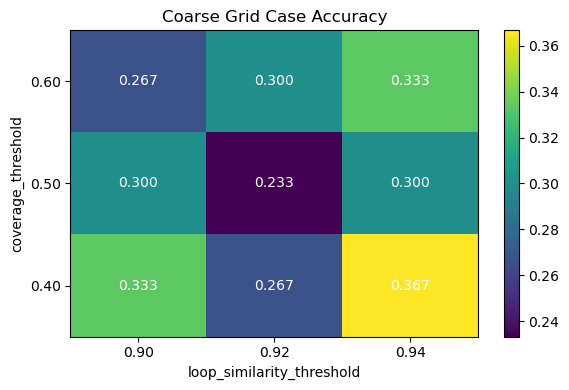

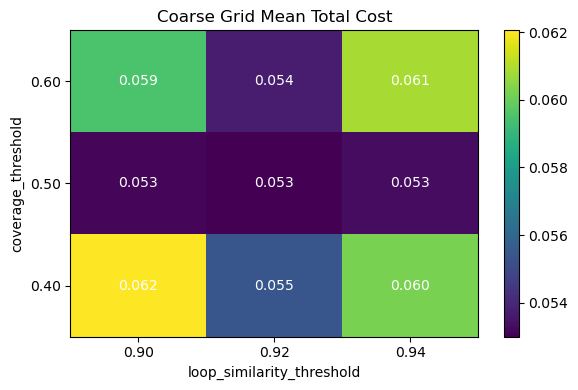

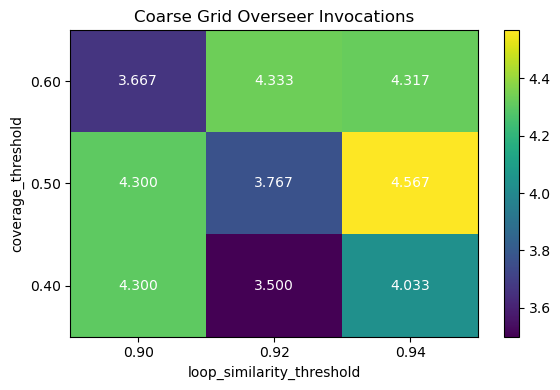

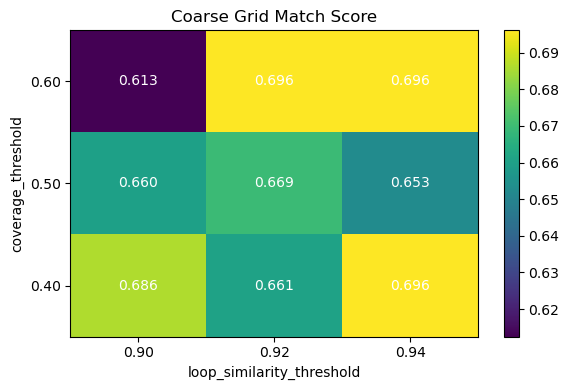

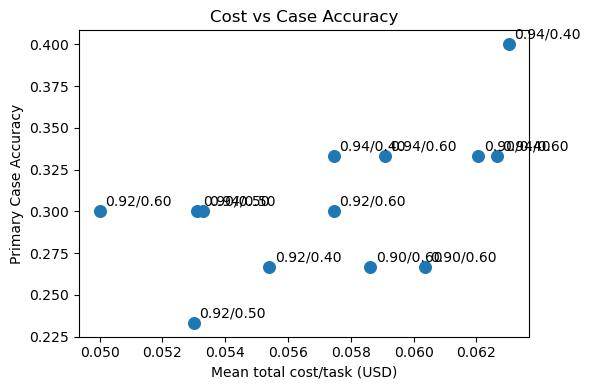

In [22]:
def plot_heatmap(summary: pd.DataFrame, value_col: str, title: str, output_path: Path) -> None:
    if summary.empty or value_col not in summary:
        print(f"Skip {title}: no data.")
        return
    primary = summary[summary["system_name"].eq("C2-noretry")].copy()
    if primary.empty:
        print(f"Skip {title}: no C2-noretry rows.")
        return
    pivot = primary.pivot_table(
        index="coverage_threshold",
        columns="loop_similarity_threshold",
        values=value_col,
        aggfunc="mean",
    ).sort_index(ascending=False)
    fig, ax = plt.subplots(figsize=(6, 4))
    image = ax.imshow(pivot.values, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), [f"{value:.2f}" for value in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), [f"{value:.2f}" for value in pivot.index])
    ax.set_xlabel("loop_similarity_threshold")
    ax.set_ylabel("coverage_threshold")
    ax.set_title(title)
    for row_index, coverage in enumerate(pivot.index):
        for col_index, similarity in enumerate(pivot.columns):
            value = pivot.loc[coverage, similarity]
            if pd.notna(value):
                ax.text(col_index, row_index, f"{value:.3f}", ha="center", va="center", color="white")
    fig.colorbar(image, ax=ax)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.show()


def plot_pareto(summary: pd.DataFrame, output_path: Path) -> None:
    if summary.empty:
        print("Skip Pareto plot: no data.")
        return
    primary = summary[summary["system_name"].eq("C2-noretry")].copy()
    if primary.empty:
        print("Skip Pareto plot: no C2-noretry rows.")
        return
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(primary["mean_total_cost_usd"], primary["primary_case_accuracy"], s=70)
    for row in primary.itertuples(index=False):
        label = f"{row.loop_similarity_threshold:.2f}/{row.coverage_threshold:.2f}"
        ax.annotate(label, (row.mean_total_cost_usd, row.primary_case_accuracy), xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("Mean total cost/task (USD)")
    ax.set_ylabel("Primary Case Accuracy")
    ax.set_title("Cost vs Case Accuracy")
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.show()


plot_heatmap(summary_with_ci, "mean_case_accuracy", "Coarse Grid Case Accuracy", FIGURE_ROOT / "coarse_case_accuracy.png")
plot_heatmap(summary_with_ci, "mean_total_cost_usd", "Coarse Grid Mean Total Cost", FIGURE_ROOT / "coarse_mean_cost.png")
plot_heatmap(summary_with_ci, "mean_overseer_invocation_count", "Coarse Grid Overseer Invocations", FIGURE_ROOT / "coarse_overseer_invocations.png")
plot_heatmap(summary_with_ci, "mean_match_score", "Coarse Grid Match Score", FIGURE_ROOT / "coarse_match_score.png")
plot_pareto(summary_with_ci, FIGURE_ROOT / "cost_accuracy_pareto.png")

## Artifact Export

In [23]:
def json_safe(value: Any) -> Any:
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, list):
        return [json_safe(item) for item in value]
    if pd.isna(value) if not isinstance(value, (dict, list, tuple, str)) else False:
        return None
    return value


def export_artifacts(summary: pd.DataFrame, ranked: pd.DataFrame, recommendation: dict[str, Any] | None) -> None:
    ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
    FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
    summary_csv = ARTIFACT_ROOT / "summary.csv"
    summary_json = ARTIFACT_ROOT / "summary.json"
    best_yaml = ARTIFACT_ROOT / "best_config.yaml"
    calibration_note = ARTIFACT_ROOT / "calibration_note.md"

    summary.to_csv(summary_csv, index=False)
    summary_json.write_text(
        json.dumps(json_safe(summary.to_dict(orient="records")), indent=2),
        encoding="utf-8",
    )
    if recommendation:
        best_payload = {
            "system": {
                "loop_similarity_threshold": float(recommendation["loop_similarity_threshold"]),
                "coverage_threshold": float(recommendation["coverage_threshold"]),
                "loop_window": FIXED_ASSUMPTIONS["loop_window"],
                "loop_repeat_count": FIXED_ASSUMPTIONS["loop_repeat_count"],
            },
            "selection": {
                "primary_objective": recommendation.get("primary_objective"),
                "mean_case_accuracy": recommendation.get("mean_case_accuracy"),
                "mean_total_cost_usd": recommendation.get("mean_total_cost_usd"),
                "overseer_invocation_rate": recommendation.get("overseer_invocation_rate"),
            },
            "ready_to_copy_overrides": [
                f"system.loop_similarity_threshold={float(recommendation['loop_similarity_threshold']):.2f}",
                f"system.coverage_threshold={float(recommendation['coverage_threshold']):.2f}",
            ],
            "not_applied": True,
        }
        best_yaml.write_text(yaml.safe_dump(json_safe(best_payload), sort_keys=False), encoding="utf-8")
        note_lines = [
            "# Shopping C2 Threshold Calibration",
            "",
            "Primary selection used C2-noretry / first-attempt logic on the frozen tune split.",
            "",
            "Recommended overrides:",
            f"- system.loop_similarity_threshold={float(recommendation['loop_similarity_threshold']):.2f}",
            f"- system.coverage_threshold={float(recommendation['coverage_threshold']):.2f}",
            "",
            "These values were generated for review only and were not applied to repo config files.",
        ]
    else:
        best_yaml.write_text("# No recommendation available yet.\nnot_applied: true\n", encoding="utf-8")
        note_lines = [
            "# Shopping C2 Threshold Calibration",
            "",
            "No completed threshold-tuning runs were available, so no recommendation was selected.",
        ]
    calibration_note.write_text("\n".join(note_lines) + "\n", encoding="utf-8")
    print(f"Wrote {summary_csv}")
    print(f"Wrote {summary_json}")
    print(f"Wrote {best_yaml}")
    print(f"Wrote {calibration_note}")


export_artifacts(summary_with_ci, ranked_df, recommended)

Wrote /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning/summary.csv
Wrote /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning/summary.json
Wrote /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning/best_config.yaml
Wrote /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning/calibration_note.md
